### Loading data..

In [55]:
# pip install kagglehub[pandas-datasets]
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\SAYHI\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


In [56]:
path+='\Tweets.csv'
df=pd.read_csv(path)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\SAYHI\AppData\Local\Temp\ipykernel_14716\3676062127.py:1: SyntaxWarning: invalid escape sequence '\T'
  path+='\Tweets.csv'


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [57]:
df=df[['text','airline_sentiment']]
df.head

<bound method NDFrame.head of                                                     text airline_sentiment
0                    @VirginAmerica What @dhepburn said.           neutral
1      @VirginAmerica plus you've added commercials t...          positive
2      @VirginAmerica I didn't today... Must mean I n...           neutral
3      @VirginAmerica it's really aggressive to blast...          negative
4      @VirginAmerica and it's a really big bad thing...          negative
...                                                  ...               ...
14635  @AmericanAir thank you we got on a different f...          positive
14636  @AmericanAir leaving over 20 minutes Late Flig...          negative
14637  @AmericanAir Please bring American Airlines to...           neutral
14638  @AmericanAir you have my money, you change my ...          negative
14639  @AmericanAir we have 8 ppl so we need 2 know h...           neutral

[14640 rows x 2 columns]>

### Preprocessing

In [58]:
import spacy
import pandas as pd
import re

# Load English spaCy model
nlp = spacy.load("en_core_web_sm")

# Sentiment-related hashtags
sentiment_hashtags = {
    "love", "happy", "fun", "awesome", "amazing", "fail", "worst", "best", "hate",
    "good", "bad", "sad", "great", "delayed", "delay", "sucks", "thankful",
    "angry", "upset", "yay", "boo", "blessed", "excited"
}

# Emoji → sentiment word mapping
emoji_map = {
    "😀": "happy", "😃": "happy", "😄": "happy", "😁": "joy", "😆": "laugh",
    "😅": "relieved", "😂": "laugh", "🤣": "laugh", "😊": "smile", "😇": "blessed",
    "😍": "love", "😘": "love", "😋": "yum", "😎": "cool", "🙂": "content",
    "😐": "neutral", "😑": "neutral", "🙃": "sarcastic", "😕": "confused",
    "😔": "sad", "😞": "sad", "😢": "cry", "😭": "cry", "😤": "angry",
    "😠": "angry", "😡": "angry", "🤬": "furious", "😩": "tired", "😫": "exhausted",
    "😱": "shocked", "😨": "scared", "😰": "nervous", "😴": "sleepy",
    "❤️": "love", "💔": "heartbroken", "👍": "approve", "👎": "disapprove",
    "🙏": "thankful", "😬": "awkward", "😒": "unimpressed", "🤔": "thinking",
    "😉": "playful", "🥰": "love", "🤗": "hug", "🤩": "excited"
}

def preprocess_text(text):
    """
    Clean and normalize text for sentiment analysis:
    - Removes mentions, URLs, stopwords, and punctuation
    - Handles negation (e.g., not_happy)
    - Converts emojis to words
    - Keeps sentiment hashtags
    """
    # Lowercase and remove URLs
    text = text.lower()
    text = re.sub(r"http\S+", "", text)

    # Process text with spaCy
    doc = nlp(text)
    tokens = []
    negate = False  # track negation

    for token in doc:
        # Skip mentions, punctuation, and spaces
        if token.text.startswith('@') or token.is_punct or token.is_space:
            continue

        # Reset negation at sentence start
        if token.is_sent_start:
            negate = False

        # Detect negation words
        if token.dep_ == "neg" or token.text in {"not", "no", "never"}:
            negate = True
            continue

        # Skip stopwords unless negation is active
        if token.is_stop and not negate:
            continue

        # Handle hashtags
        if token.text.startswith('#'):
            tag = token.text[1:]
            if tag in sentiment_hashtags:
                tokens.append(tag)
            continue

        # Map known emojis
        if token.text in emoji_map:
            tokens.append(emoji_map[token.text])
            continue

        # Detect other emojis (non-ASCII characters)
        if any(ord(char) > 128 for char in token.text):
            tokens.append("emoji")
            continue

        # Lemmatize word
        lemma = token.lemma_

        # Apply negation
        if negate:
            lemma = f"not_{lemma}"
            negate = False

        tokens.append(lemma)

    return " ".join(tokens)


# Apply preprocessing
df["clean_text"] = df["text"].apply(preprocess_text)

# Display results
print(df[["text", "clean_text"]])


                                                    text  \
0                    @VirginAmerica What @dhepburn said.   
1      @VirginAmerica plus you've added commercials t...   
2      @VirginAmerica I didn't today... Must mean I n...   
3      @VirginAmerica it's really aggressive to blast...   
4      @VirginAmerica and it's a really big bad thing...   
...                                                  ...   
14635  @AmericanAir thank you we got on a different f...   
14636  @AmericanAir leaving over 20 minutes Late Flig...   
14637  @AmericanAir Please bring American Airlines to...   
14638  @AmericanAir you have my money, you change my ...   
14639  @AmericanAir we have 8 ppl so we need 2 know h...   

                                              clean_text  
0                                                    say  
1                   plus add commercial experience tacky  
2                               not_today mean need trip  
3      aggressive blast obnoxious entertain

In [59]:
df['clean_text'].head(60)

0                                                   say
1                  plus add commercial experience tacky
2                              not_today mean need trip
3     aggressive blast obnoxious entertainment guest...
4                                         big bad thing
5     seriously pay $ 30 flight seat not_have playin...
6      yes nearly time fly vx ear worm will not_go away
7                 miss prime opportunity man hat parody
8                                             didn't -d
9                        amazing arrive hour early good
10      know suicide second lead cause death teen 10 24
11       lt;3 pretty graphic well minimal iconography d
12    great deal think 2nd trip amp not_even go 1st ...
13      fly fabulous seductive sky u stress away travel
14                                                thank
15                                 sfo pdx schedule mia
16    excited cross country flight lax mco hear grea...
17    fly nyc sfo week not_fully sit seat large 

###  Converting text to numerical features using TF-IDF

In [60]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=1000)  # limit to top 1000 features
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Convert to DataFrame for inspection
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df_tfidf.head(10)


,000,10,100,11,12,13,14,15,16,17,...,wrong,wtf,yeah,year,yep,yes,yesterday,you,yr,zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.394605,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


### Training and evaluating classification models (Logistic Regression, SVM)

In [61]:
df['airline_sentiment']=df['airline_sentiment'].map({'positive':1, 'neutral':0, 'negative':-1})
df['airline_sentiment'].head

<bound method NDFrame.head of 0        0
1        1
2        0
3       -1
4       -1
        ..
14635    1
14636   -1
14637    0
14638   -1
14639    0
Name: airline_sentiment, Length: 14640, dtype: int64>

In [62]:


import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
# Labels
y = df['airline_sentiment']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_tfidf, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 3️⃣ Logistic Regression
# =========================
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# =========================
# 4️⃣ Support Vector Machine (SVM)
# =========================
svm_model = SVC(kernel='linear')  # linear kernel works well with TF-IDF
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


=== Logistic Regression ===
Accuracy: 0.782103825136612
              precision    recall  f1-score   support

          -1       0.82      0.92      0.87      2753
           0       0.63      0.49      0.55       930
           1       0.78      0.62      0.69       709

    accuracy                           0.78      4392
   macro avg       0.74      0.68      0.70      4392
weighted avg       0.77      0.78      0.77      4392

=== SVM ===
Accuracy: 0.7750455373406193
              precision    recall  f1-score   support

          -1       0.82      0.91      0.86      2753
           0       0.61      0.48      0.54       930
           1       0.76      0.64      0.70       709

    accuracy                           0.78      4392
   macro avg       0.73      0.68      0.70      4392
weighted avg       0.76      0.78      0.77      4392



### Visualize most informative features

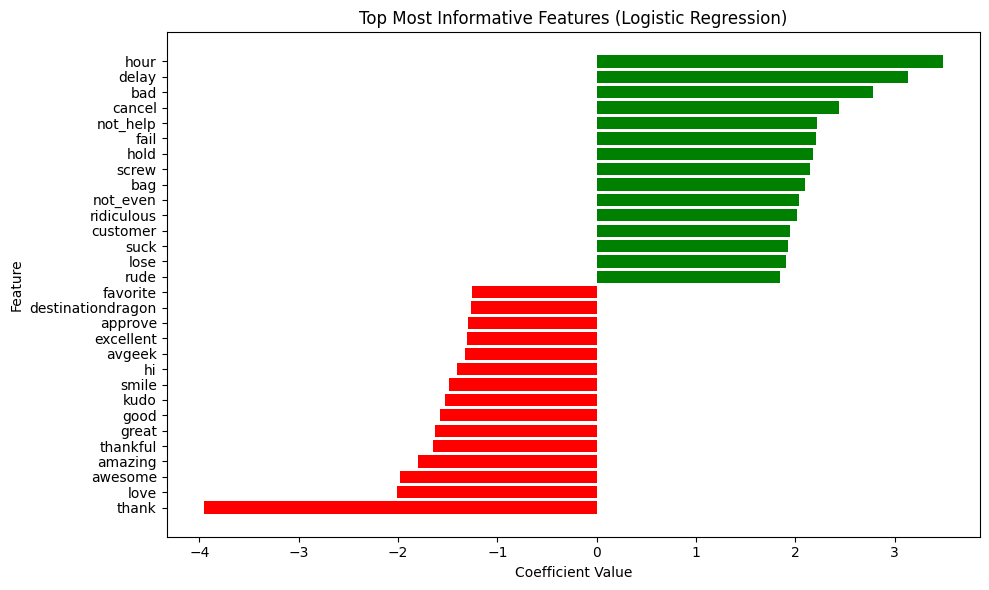

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Feature names: TF-IDF + sentiment features
tfidf_features = tfidf.get_feature_names_out()

# Get coefficients from Logistic Regression
coef = lr_model.coef_[0]  # For binary/multi-class, adjust index

# Get top positive and negative features
top_n = 15
top_positive_idx = np.argsort(coef)[-top_n:]
top_negative_idx = np.argsort(coef)[:top_n]

top_features = np.concatenate([top_negative_idx, top_positive_idx])
top_coef = coef[top_features]
top_feature_names = tfidf_features[top_features]

# Plot
plt.figure(figsize=(10,6))
colors = ['red']*top_n + ['green']*top_n
plt.barh(range(2*top_n), top_coef, color=colors)
plt.yticks(range(2*top_n), top_feature_names)
plt.title("Top Most Informative Features (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


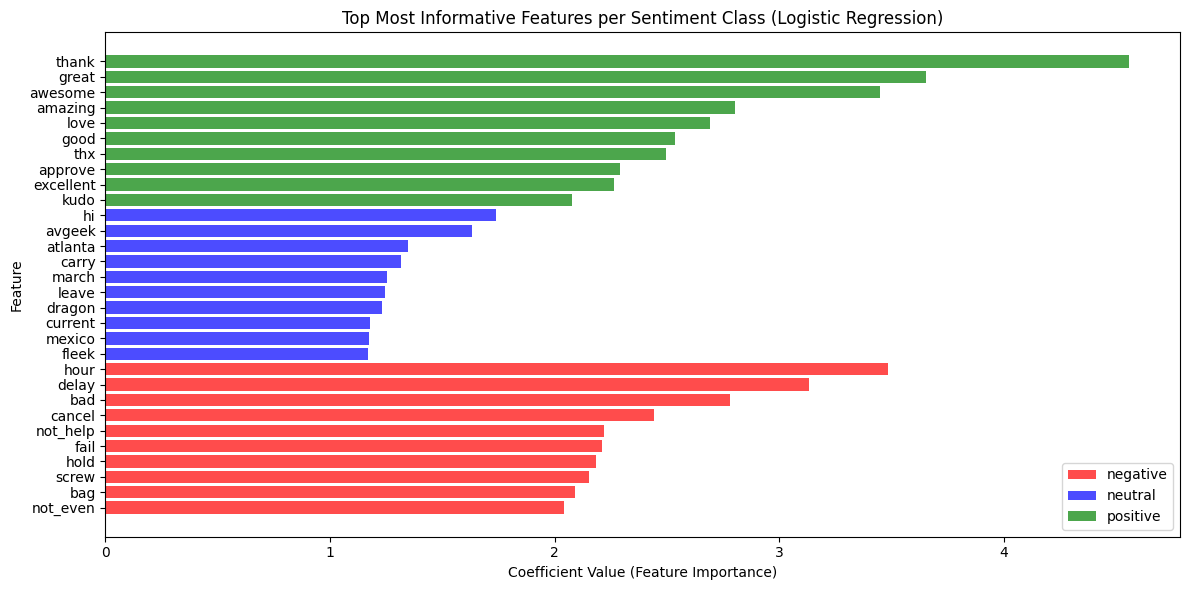

In [66]:
# Number of top features per class
top_n = 10
classes = lr_model.classes_  # ['negative', 'neutral', 'positive']

# Collect top features for all classes
top_features_all = []

for i, class_label in enumerate(classes):
    coef = lr_model.coef_[i]
    top_idx = np.argsort(coef)[-top_n:]  # top N
    for idx in top_idx:
        top_features_all.append({
            'class': class_label,
            'feature': tfidf_features[idx],
            'coef': coef[idx]
        })

# Convert to DataFrame for easy plotting
df_top = pd.DataFrame(top_features_all)

# Plot grouped bar chart
plt.figure(figsize=(12, 6))

# Map numeric classes to string labels
class_label_map = {
    -1: "negative",
     0: "neutral",
     1: "positive"
}

colors = {'positive': 'green', 'neutral': 'blue', 'negative': 'red'}

for cls in classes:
    label = class_label_map[cls]   # map numeric → string
    subset = df_top[df_top['class'] == cls].sort_values('coef', ascending=True)
    plt.barh(subset['feature'], subset['coef'], color=colors[label], label=label, alpha=0.7)

plt.title("Top Most Informative Features per Sentiment Class (Logistic Regression)")
plt.xlabel("Coefficient Value (Feature Importance)")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()


### Model analysis and potential improvements

- The models do well on negative tweets (most common and clear signals like “delay”, “worst”, “angry”).

- Neutral tweets are hard — often lack strong sentiment cues (“Flight arrived”, “At the gate now”).

- Positive tweets are fewer in data → class imbalance + more subtle language → lower recall.


#### Feature Insights

From your “Top Informative Features” visualization:

- Positive: “thank”, “love”, “great”, “awesome”, “amazing”, “thank_you”

- Negative: “delay”, “cancelled”, “bad”, “wtf”, “late”, “sucks”, “angry”

- Neutral: words like “flight”, “airport”, “gate”, “today”

✅ Clear pattern — sentiment-heavy tokens dominate the extremes, while neutral features are generic.
This confirms your preprocessing + TF-IDF worked correctly.


#### Potential Issues

1. ⚠️ Class Imbalance

- Negative tweets dominate this dataset (~60%), positives are rare (~16%).

- This biases the model toward predicting negatives.

2. 💬 Ambiguous Tweets

- Some “neutral” tweets may include mild emotion (“just landed!” → not clearly positive or neutral).

- Models trained only on lexical cues often misread tone.

3. 🧹 Feature Sparsity

- TF-IDF is high-dimensional (up to 5,000–10,000 features), but doesn’t capture meaning.

- Words like “good” and “great” treated as unrelated.

4. 🙈 Context Missing

- Phrases like “not bad” → bag-of-words sees “bad”, misses negation context (though you handled some negations).

### Recommendations for Improvement

A. Handle Class Imbalance

* Use class weighting in Logistic Regression or SVM:

        lr = LogisticRegression(class_weight='balanced')


* Or apply SMOTE / RandomOverSampler on the minority classes.



B. Enrich Preprocessing

✅ You already handle negations and emojis — great.

* Add emoji sentiment scoring (you started mapping them, could expand).

* Add bigram/trigram phrases (e.g., “thank you”, “not happy”) — TF-IDF ngram_range=(1,2) already helps.



C. Improve Feature Representation

* Move from TF-IDF → Word Embeddings:

    - Use Sentence-BERT (e.g., all-MiniLM-L6-v2) for semantic representation.

    - These capture contextual meaning (“not bad” → positive).

    Example:

        from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    X_embed = model.encode(df["clean_text"])


    - Train Logistic Regression / Random Forest on those embeddings.



D. Try Transformer Fine-Tuning

For best accuracy, fine-tune a pretrained sentiment model:

    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


Models to consider:

* distilbert-base-uncased

* cardiffnlp/twitter-roberta-base-sentiment-latest

These models:

* Understand context, sarcasm, negations

* Already trained on tweet sentiment datasets

Expect +5–10% improvement in F1.



E. Add Explainability

You can add:

* SHAP / LIME to visualize why a tweet was predicted as positive/negative.

* This helps in interpreting borderline cases.